# 📡 Customer Churn Prediction for Telecom Companies
**Capstone Project — Predictive Analytics**

**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Objective:** Predict which customers are likely to churn using Machine Learning

---

## TABLE OF CONTENTS
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Model Comparison
7. Feature Importance & Interpretation
8. Conclusions & Recommendations

In [7]:
# ─── IMPORTS ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

# Additional
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
})

COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'success': '#43e97b',
    'danger': '#f5576c',
    'warning': '#f7971e',
    'info': '#4facfe',
    'churn': ['#43e97b', '#f5576c'],  # No, Yes
}

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 1. Data Loading & Exploration

In [8]:
# Load dataset
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{list(df.columns)}")

Dataset Shape: 7043 rows × 21 columns

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
# First 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Descriptive statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing: {df.isnull().sum().sum()}")

Missing Values per Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total Missing: 0


In [13]:
# Check unique values for each column
print("Unique Values per Column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique()[:5]}...")

Unique Values per Column:
  customerID: 7043 unique → ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']...
  gender: 2 unique → ['Female' 'Male']...
  SeniorCitizen: 2 unique → [0 1]...
  Partner: 2 unique → ['Yes' 'No']...
  Dependents: 2 unique → ['No' 'Yes']...
  tenure: 73 unique → [ 1 34  2 45  8]...
  PhoneService: 2 unique → ['No' 'Yes']...
  MultipleLines: 3 unique → ['No phone service' 'No' 'Yes']...
  InternetService: 3 unique → ['DSL' 'Fiber optic' 'No']...
  OnlineSecurity: 3 unique → ['No' 'Yes' 'No internet service']...
  OnlineBackup: 3 unique → ['Yes' 'No' 'No internet service']...
  DeviceProtection: 3 unique → ['No' 'Yes' 'No internet service']...
  TechSupport: 3 unique → ['No' 'Yes' 'No internet service']...
  StreamingTV: 3 unique → ['No' 'Yes' 'No internet service']...
  StreamingMovies: 3 unique → ['No' 'Yes' 'No internet service']...
  Contract: 3 unique → ['Month-to-month' 'One year' 'Two year']...
  PaperlessBilling: 2 unique → ['Yes' 'No']...

---
## 2. Data Cleaning & Preprocessing

In [14]:
# Fix TotalCharges — has blank strings instead of NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaN count: {df['TotalCharges'].isna().sum()}")

# Show the problematic rows
print("\nRows with missing TotalCharges:")
print(df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

TotalCharges NaN count: 11

Rows with missing TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [15]:
# Impute missing TotalCharges with tenure * MonthlyCharges
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'tenure'] * df.loc[mask, 'MonthlyCharges']
df['TotalCharges'].fillna(0, inplace=True)

print(f"Missing values after fix: {df['TotalCharges'].isna().sum()}")

Missing values after fix: 0


In [16]:
# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)
print(f"Shape after dropping customerID: {df.shape}")

Shape after dropping customerID: (7043, 20)


In [17]:
# Convert SeniorCitizen from 0/1 to No/Yes for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

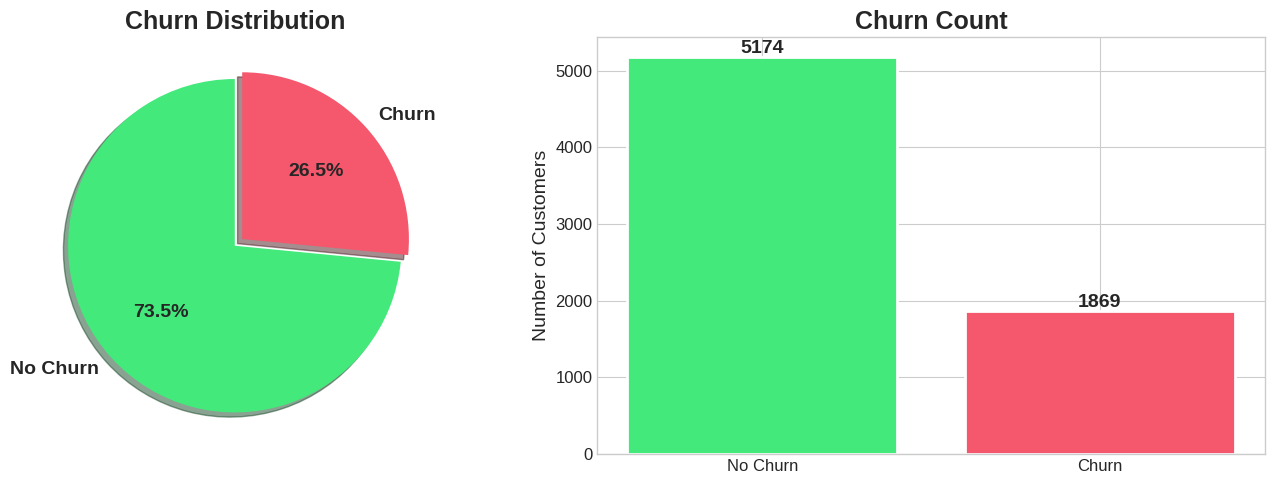


Churn Rate: 26.5%
Class Imbalance Ratio: 2.77:1


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts.values, labels=['No Churn', 'Churn'],
    autopct='%1.1f%%', colors=COLORS['churn'],
    explode=(0, 0.06), shadow=True,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    startangle=90
)
axes[0].set_title('Churn Distribution', fontsize=18, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['No Churn', 'Churn'], churn_counts.values,
    color=COLORS['churn'], edgecolor='white', linewidth=2
)
for bar, count in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{count}', ha='center', fontsize=14, fontweight='bold')
axes[1].set_title('Churn Count', fontsize=18, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")
print(f"Class Imbalance Ratio: {churn_counts['No'] / churn_counts['Yes']:.2f}:1")

### 3.2 Categorical Features vs Churn

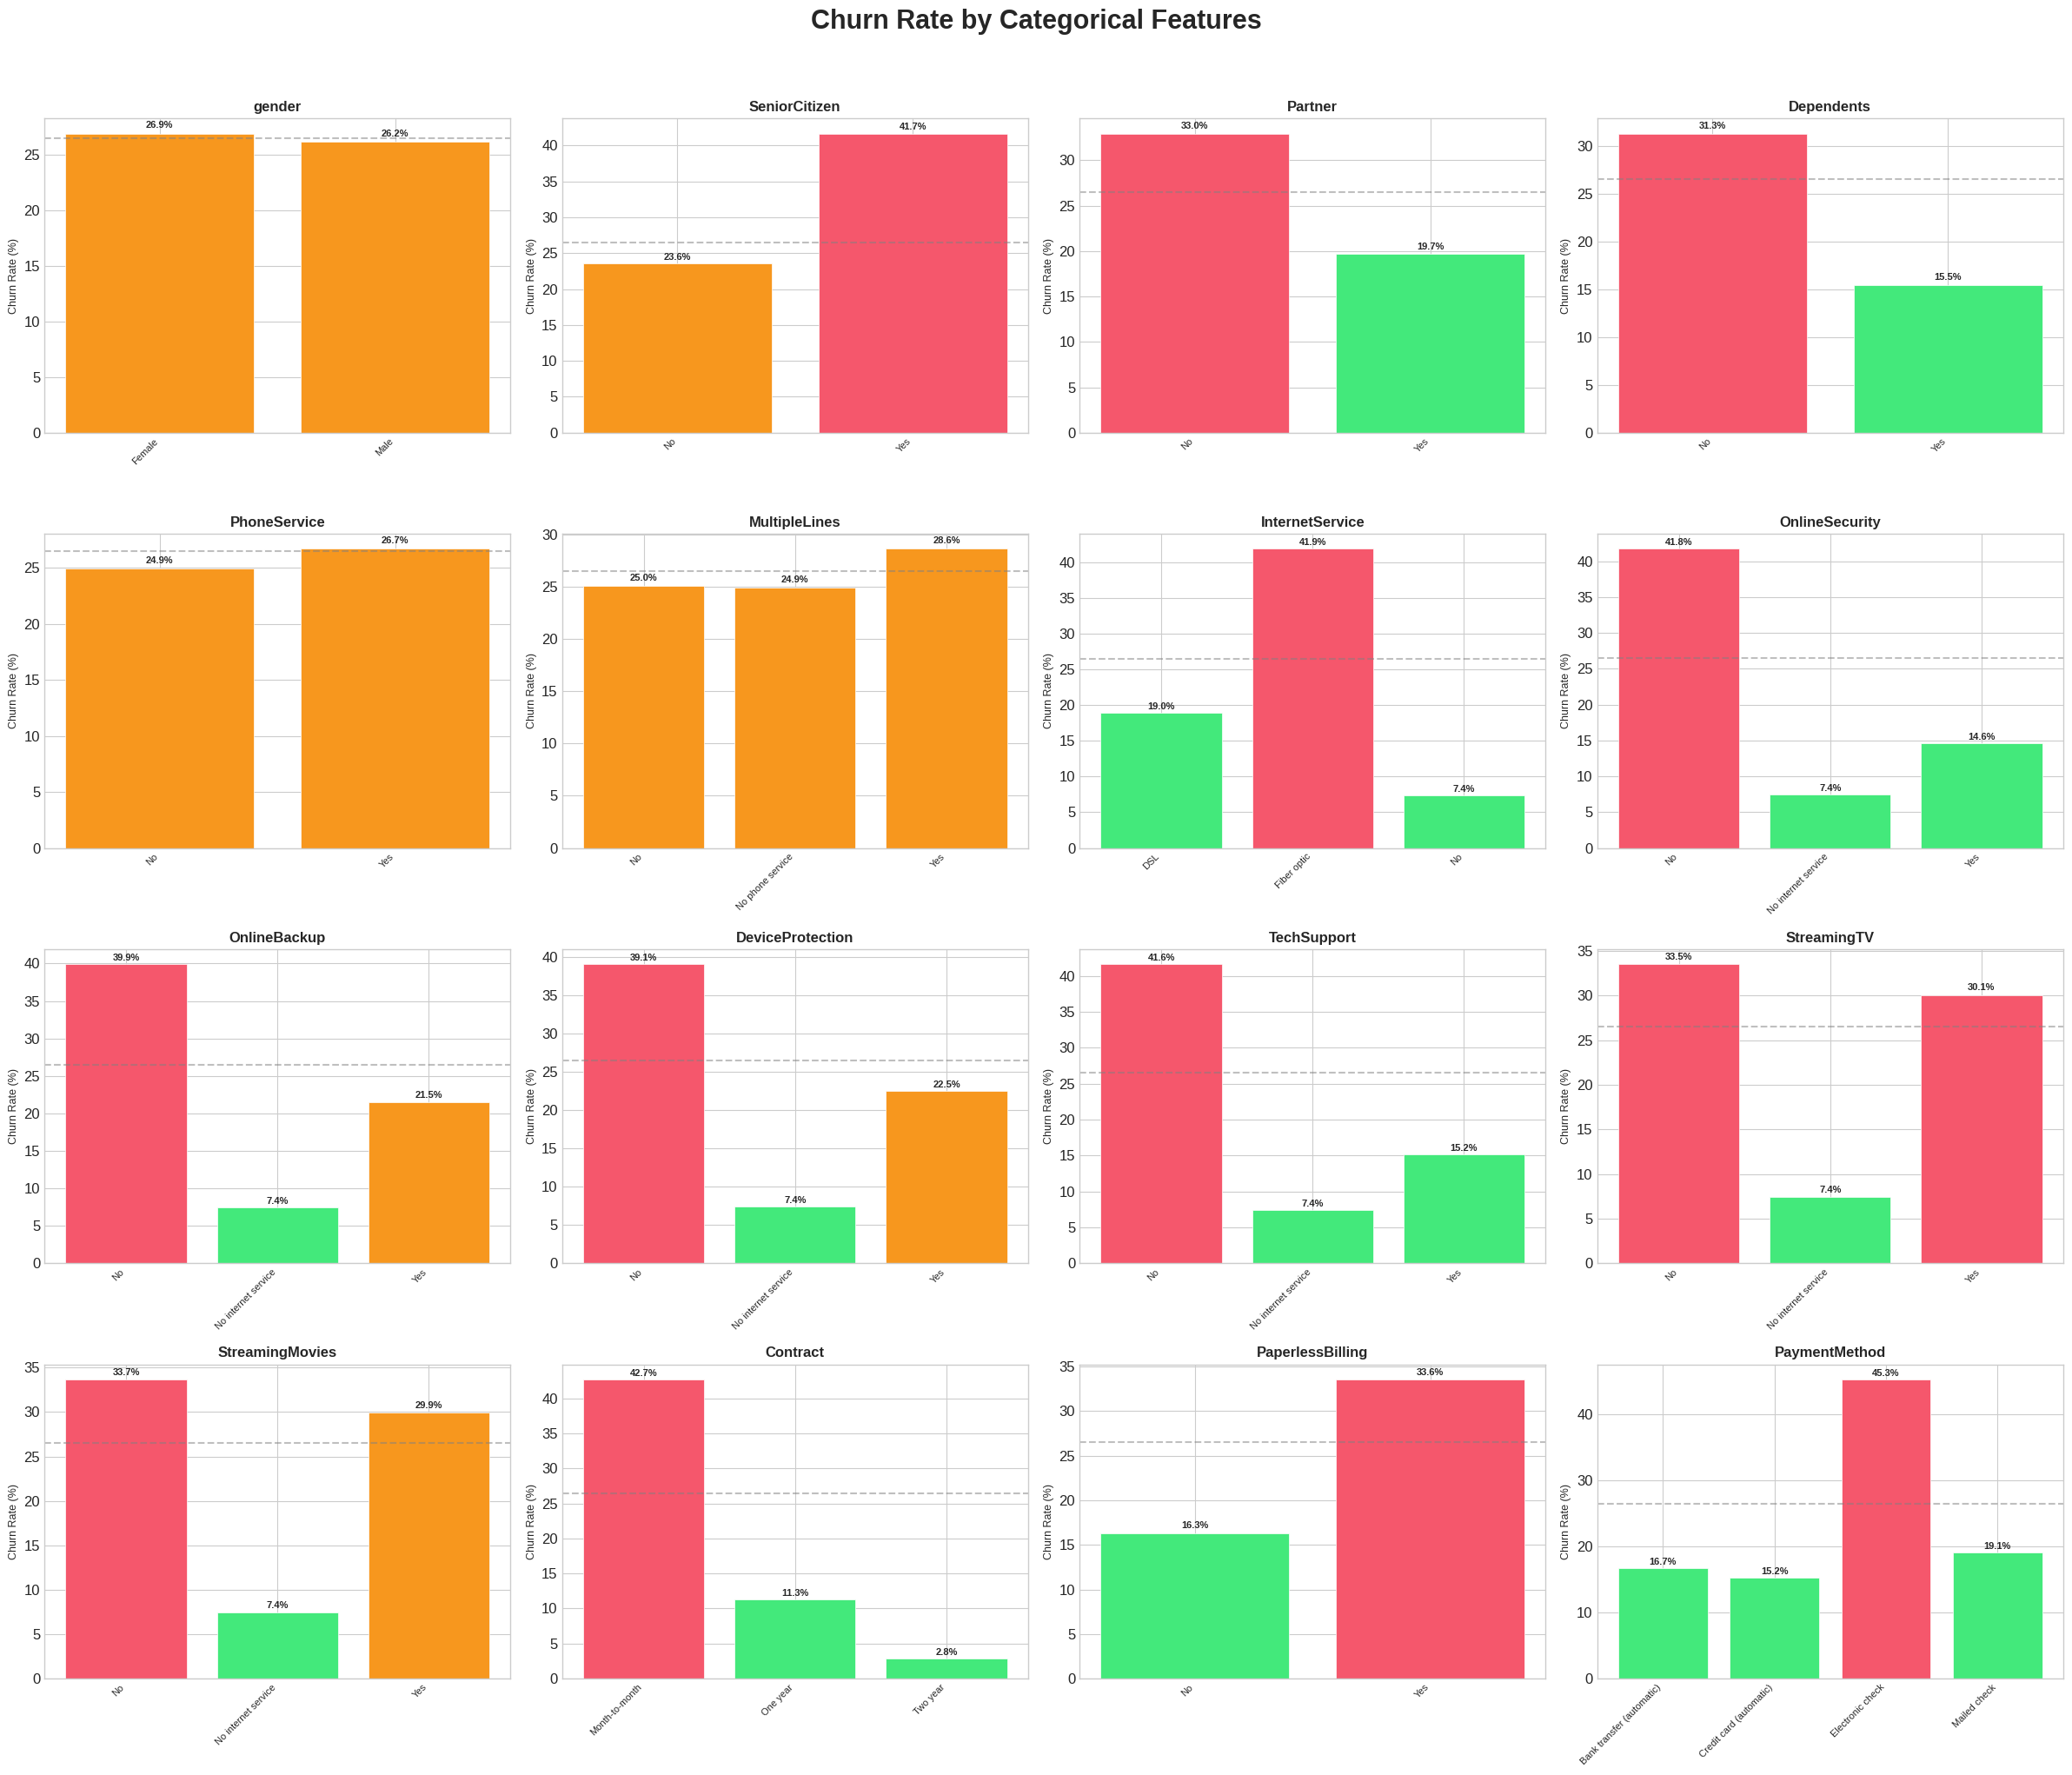

In [20]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    churn_rates = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    bars = axes[i].bar(
        range(len(churn_rates)), churn_rates.values,
        color=[COLORS['danger'] if v > 30 else COLORS['warning'] if v > 20 else COLORS['success'] for v in churn_rates.values],
        edgecolor='white', linewidth=0.5
    )
    axes[i].set_xticks(range(len(churn_rates)))
    axes[i].set_xticklabels(churn_rates.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)', fontsize=9)
    axes[i].axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg')

    # Add value labels
    for bar, val in zip(bars, churn_rates.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Numerical Features Distribution

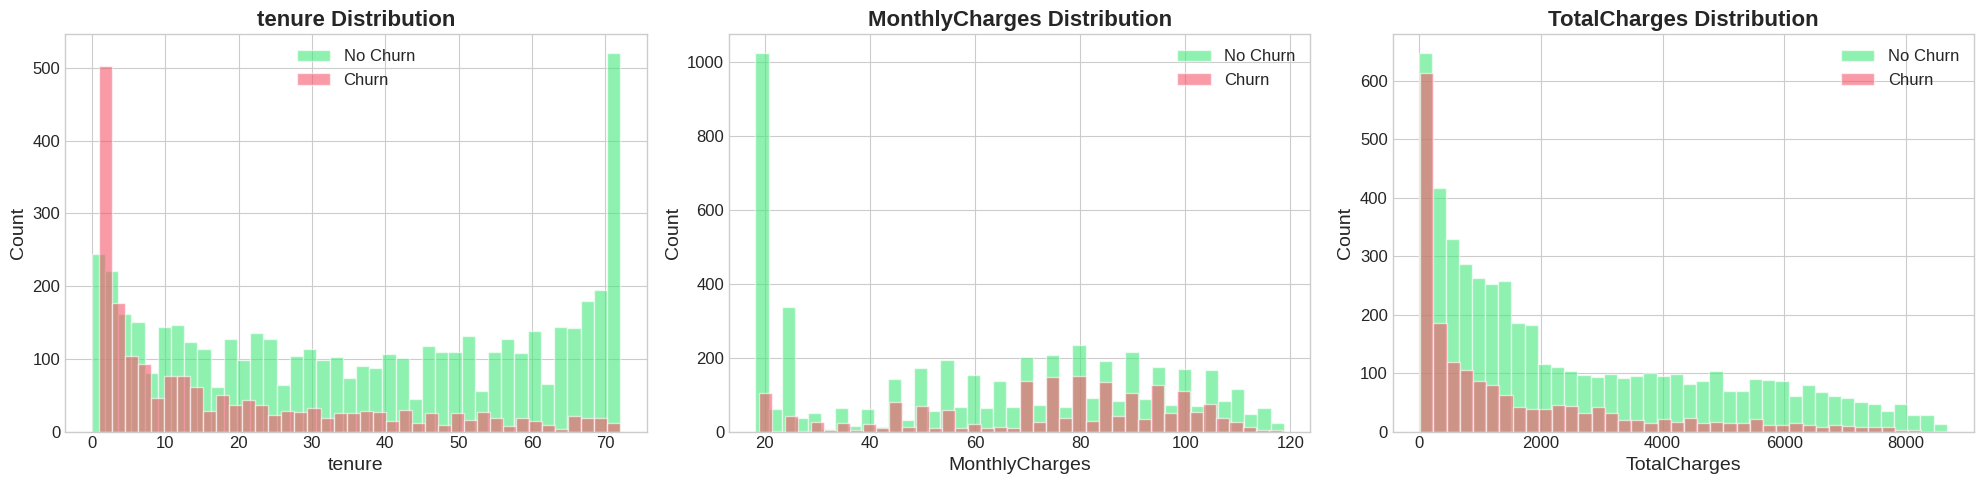

In [21]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_cols):
    for churn_val, color, label in [('No', COLORS['success'], 'No Churn'), ('Yes', COLORS['danger'], 'Churn')]:
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')

    axes[i].set_title(f'{col} Distribution', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.show()

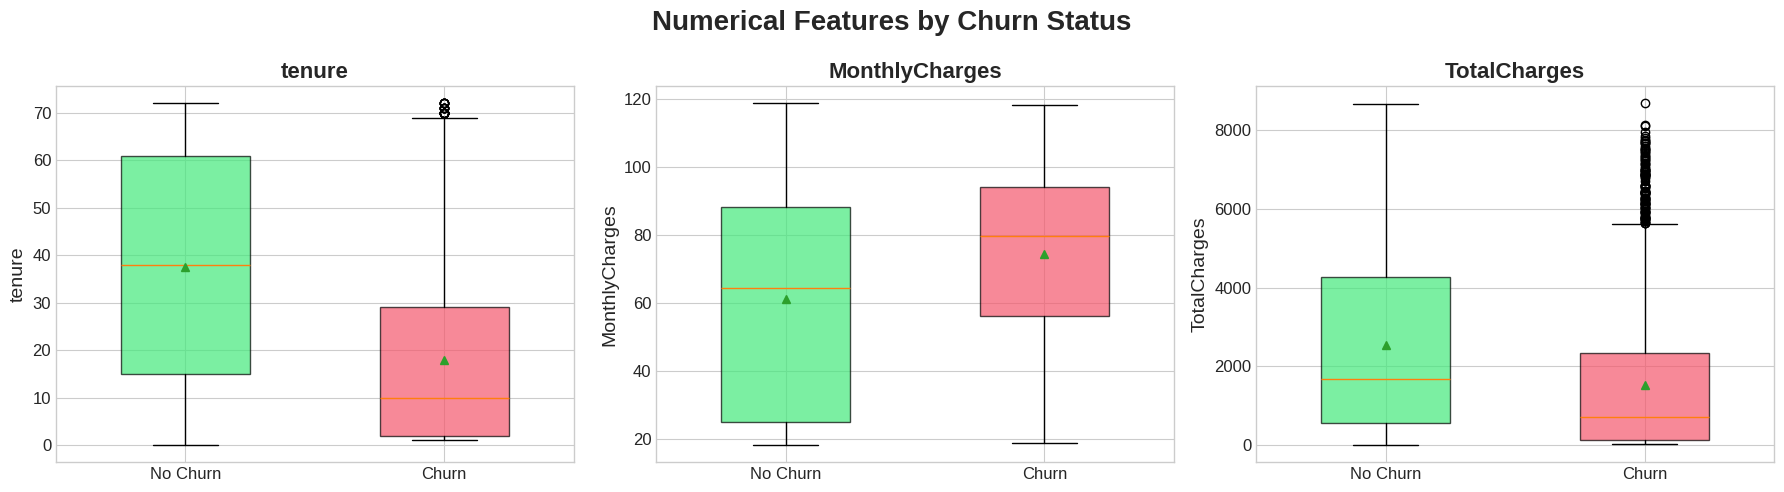

In [22]:
# Box plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    data = [df[df['Churn'] == 'No'][col], df[df['Churn'] == 'Yes'][col]]
    bp = axes[i].boxplot(data, labels=['No Churn', 'Churn'], patch_artist=True,
                         widths=0.5, showmeans=True)
    bp['boxes'][0].set_facecolor(COLORS['success'])
    bp['boxes'][1].set_facecolor(COLORS['danger'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[i].set_title(f'{col}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features by Churn Status', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

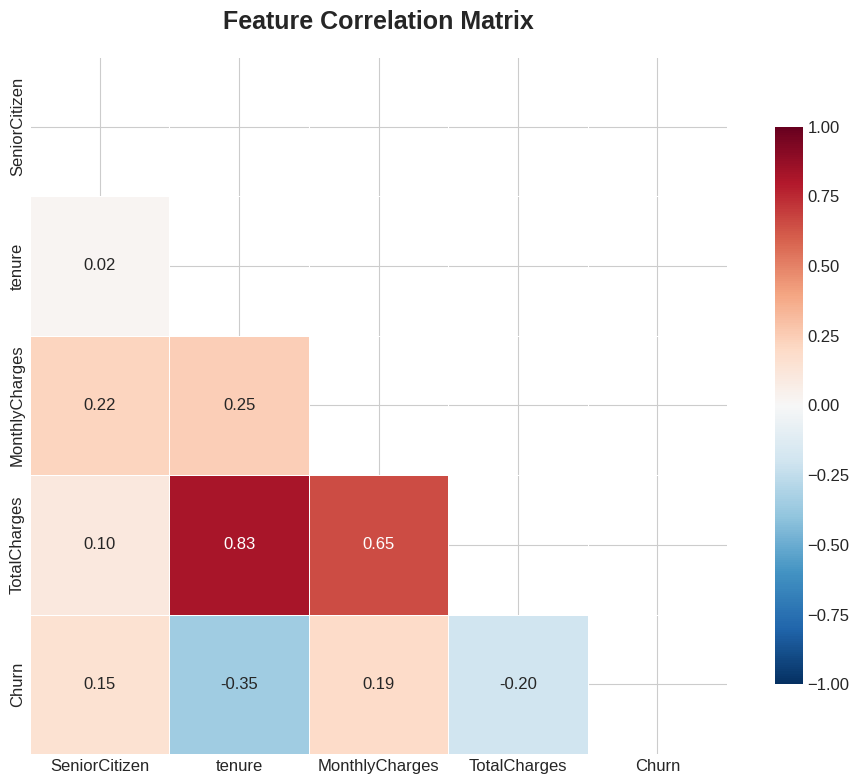

In [23]:
# Encode for correlation
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].map({'Yes': 1, 'No': 0})

# Select numeric columns
numeric_df = df_corr.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


Correlation with Churn:
tenure           -0.352229
TotalCharges     -0.198324
SeniorCitizen     0.150889
MonthlyCharges    0.193356


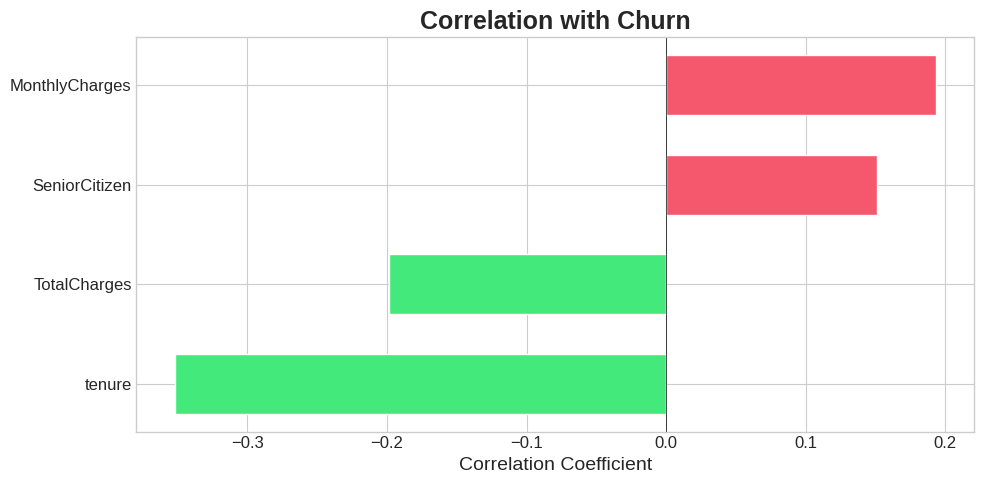

In [24]:
# Correlation with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values()
print("\nCorrelation with Churn:")
print(churn_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['danger'] if v > 0 else COLORS['success'] for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white', height=0.6)
ax.set_title('Correlation with Churn', fontsize=18, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### 3.5 Key Insights from EDA

**High Churn Segments:**
- Month-to-month contracts (42.7% churn vs ~3% for two-year)
- Fiber optic internet (41.9% churn)
- Electronic check payment (45.3% churn)  
- No tech support / No online security (~42% churn each)
- Senior Citizens (41.7% churn)
- New customers (tenure < 12 months)

**Low Churn Segments:**
- Two-year contracts (~3% churn)
- DSL internet (~19% churn)
- Customers with add-on services (security, backup, support)
- Long-tenure customers (48+ months)

---
## 4. Feature Engineering

In [33]:
# Create derived features
df_eng = df.copy()

# Average monthly charge
df_eng['AvgMonthlyCharge'] = np.where(
    df_eng['tenure'] > 0,
    df_eng['TotalCharges'] / df_eng['tenure'],
    df_eng['MonthlyCharges']
)

# Number of services
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

def count_services(row):
    count = 0
    for col in service_cols:
        val = str(row[col]).strip()
        if val in ('Yes', 'Fiber optic', 'DSL'):
            count += 1
    return count

df_eng['NumServices'] = df_eng.apply(count_services, axis=1)

# Tenure grouping
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12', '13-24', '25-48', '49-60', '61-72']
df_eng['TenureGroup'] = pd.cut(df_eng['tenure'], bins=bins, labels=labels, include_lowest=True)

print(f"New features added. Shape: {df_eng.shape}")
print(f"\nNew columns: AvgMonthlyCharge, NumServices, TenureGroup")

New features added. Shape: (7043, 23)

New columns: AvgMonthlyCharge, NumServices, TenureGroup


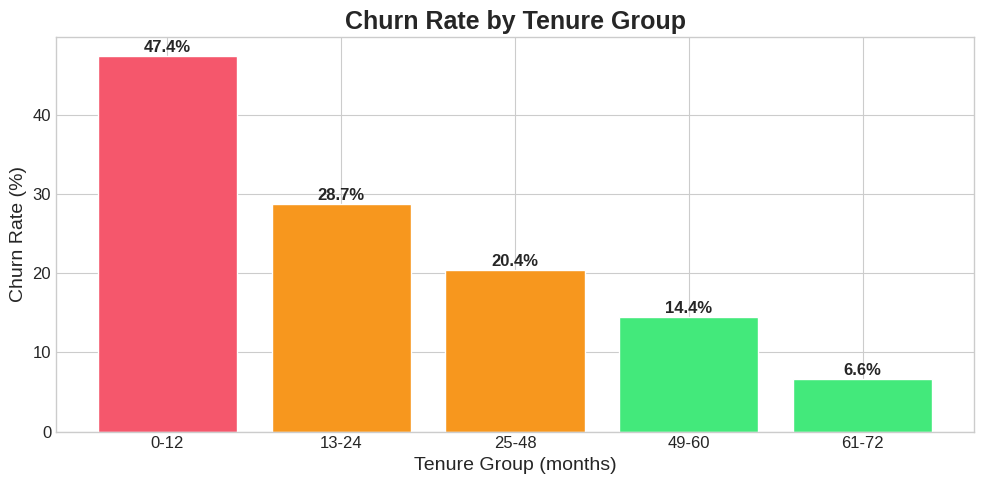

In [34]:
# Tenure Group vs Churn
fig, ax = plt.subplots(figsize=(10, 5))
tenure_churn = df_eng.groupby('TenureGroup')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color=[COLORS['danger'] if v > 30 else COLORS['warning'] if v > 20 else COLORS['success'] for v in tenure_churn.values],
              edgecolor='white')
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate by Tenure Group', fontsize=18, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group (months)')
plt.tight_layout()
plt.show()

---
## 5. Model Training & Evaluation

In [35]:
# Prepare data for modeling
y = df_eng['Churn'].map({'Yes': 1, 'No': 0})
df_model = df_eng.drop(['Churn', 'TenureGroup'], axis=1)

# Binary encode Yes/No columns
for col in df_model.select_dtypes(include='object').columns:
    if set(df_model[col].unique()).issubset({'Yes', 'No'}):
        df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categoricals
cat_cols_remaining = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols_remaining, drop_first=True)

# Scale numerical features
num_cols_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'NumServices']
scaler = StandardScaler()
df_model[num_cols_scale] = scaler.fit_transform(df_model[num_cols_scale])

feature_names = df_model.columns.tolist()
X = df_model.values

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")
print(f"Churn rate: {y.mean():.2%}")

Feature matrix: (7043, 32)
Target: (7043,)
Churn rate: 26.54%


In [36]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")

Train: 5634 samples | Test: 1409 samples
Train churn rate: 26.54% | Test churn rate: 26.54%


In [37]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE:  {np.bincount(y_train_sm)}")


Before SMOTE: [4139 1495]
After SMOTE:  [4139 4139]


### 5.1 Train All Models

In [38]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=42, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                                 random_state=42, verbose=-1),
}

# Train and evaluate
results = {}
all_metrics = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")

    model.fit(X_train_sm, y_train_sm)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    }
    all_metrics.append(metrics)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob}

    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

metrics_df = pd.DataFrame(all_metrics)
print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)
metrics_df


  Training: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Training: Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409


  Training: SVM
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      14

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.737402,0.503367,0.799465,0.617769,0.840032
1,Random Forest,0.765082,0.543611,0.716578,0.618224,0.842267
2,SVM,0.755855,0.527881,0.759358,0.622807,0.822991
3,XGBoost,0.770050,0.566845,0.566845,0.566845,0.832717
4,LightGBM,0.771469,0.571823,0.553476,0.562500,0.828271


---
## 6. Model Comparison

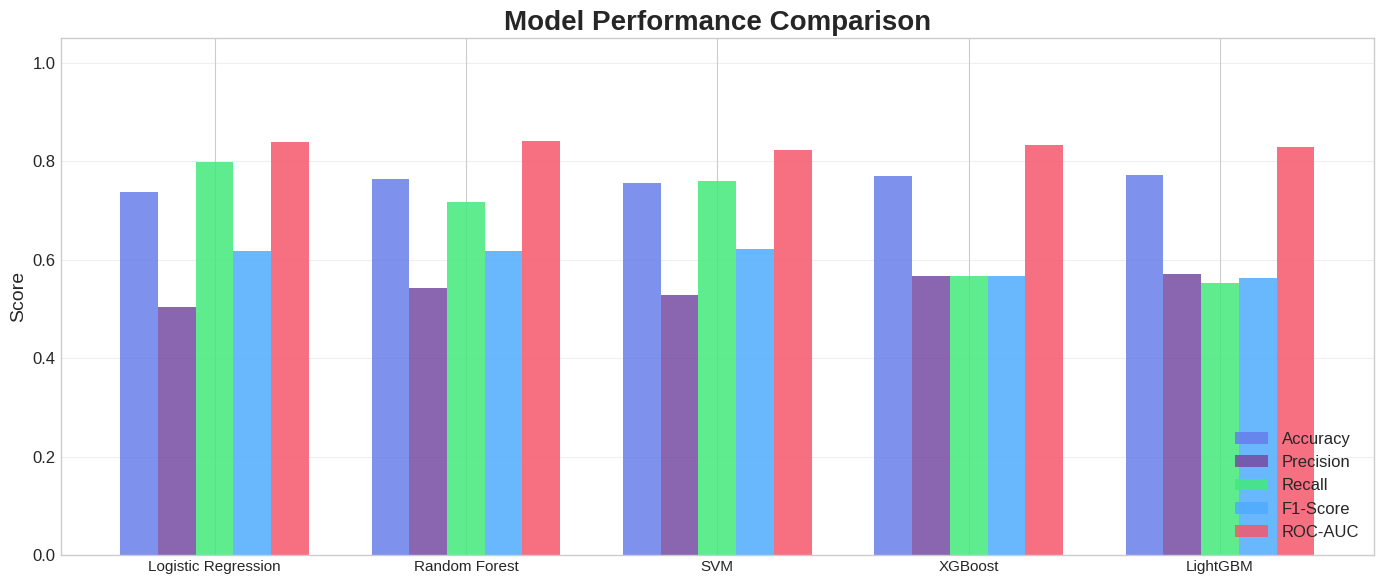

In [39]:
# Metrics comparison chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_df))
width = 0.15
metric_cols_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors_plot = [COLORS['primary'], COLORS['secondary'], COLORS['success'], COLORS['info'], COLORS['danger']]

for i, metric in enumerate(metric_cols_plot):
    ax.bar(x + i*width, metrics_df[metric], width, label=metric, color=colors_plot[i], alpha=0.85)

ax.set_xticks(x + 2*width)
ax.set_xticklabels(metrics_df['Model'], fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=20, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

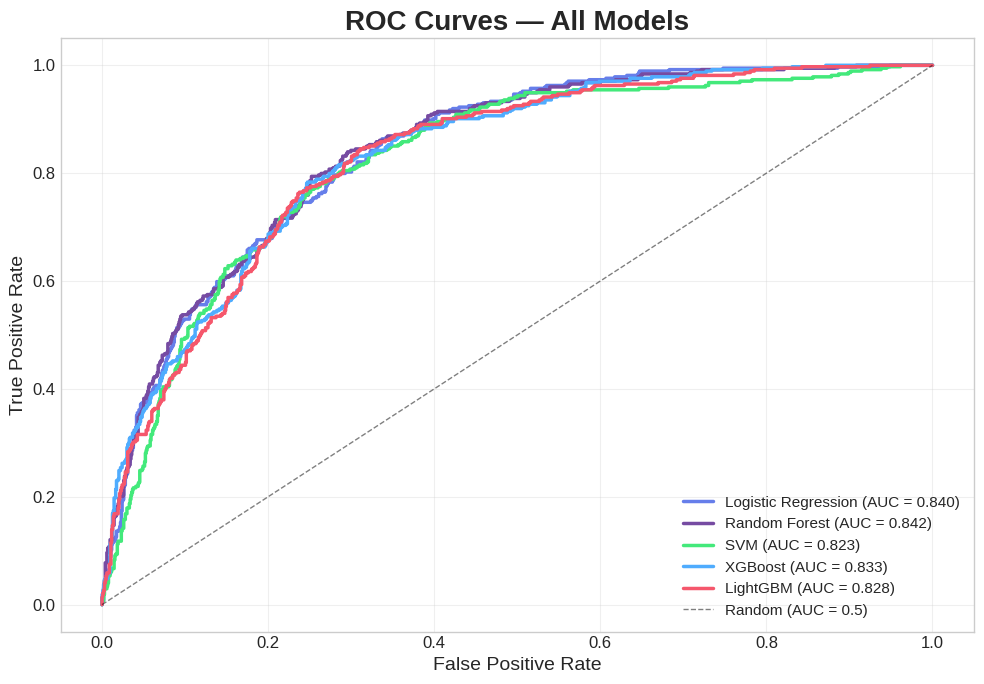

In [40]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = [COLORS['primary'], COLORS['secondary'], COLORS['success'], COLORS['info'], COLORS['danger']]

for i, (name, data) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=2.5,
            label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curves — All Models', fontsize=20, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

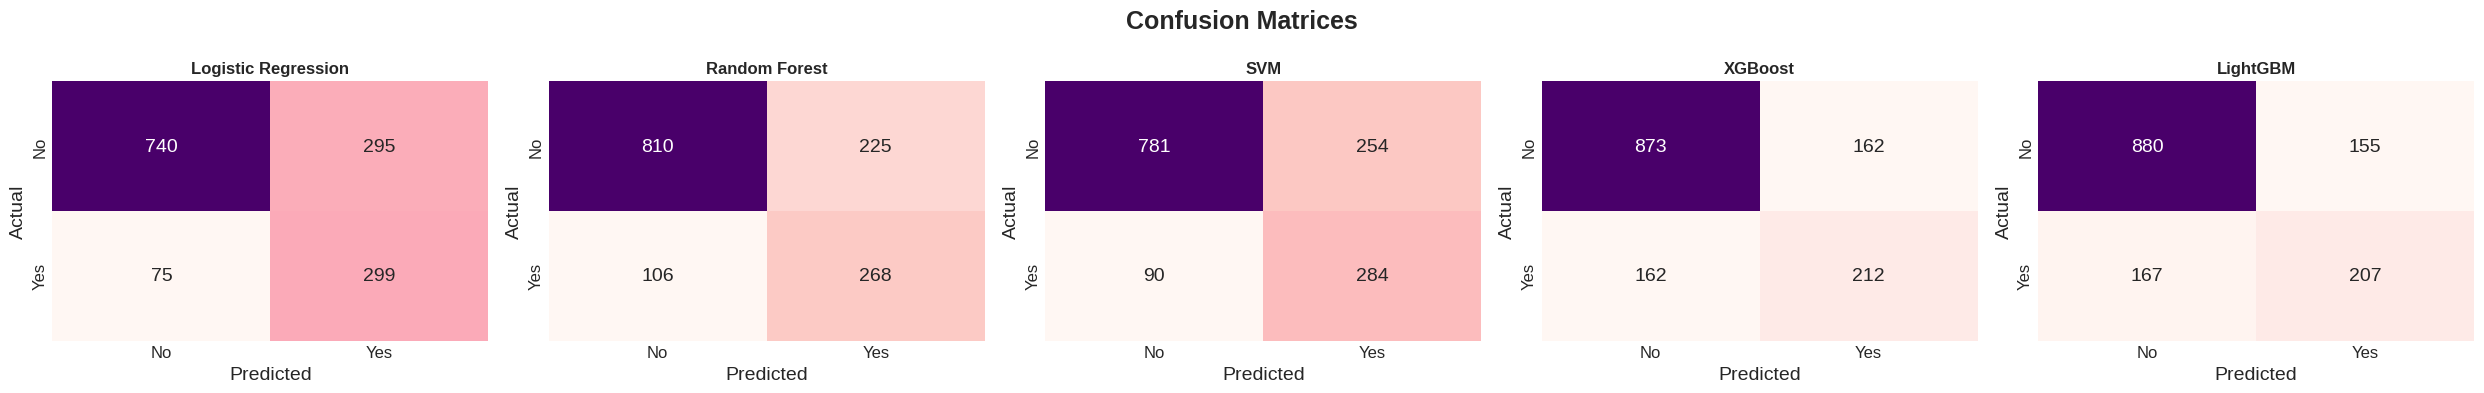

In [41]:
# Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                ax=axes[i], cbar=False, annot_kws={'size': 14})
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Feature Importance & Interpretation

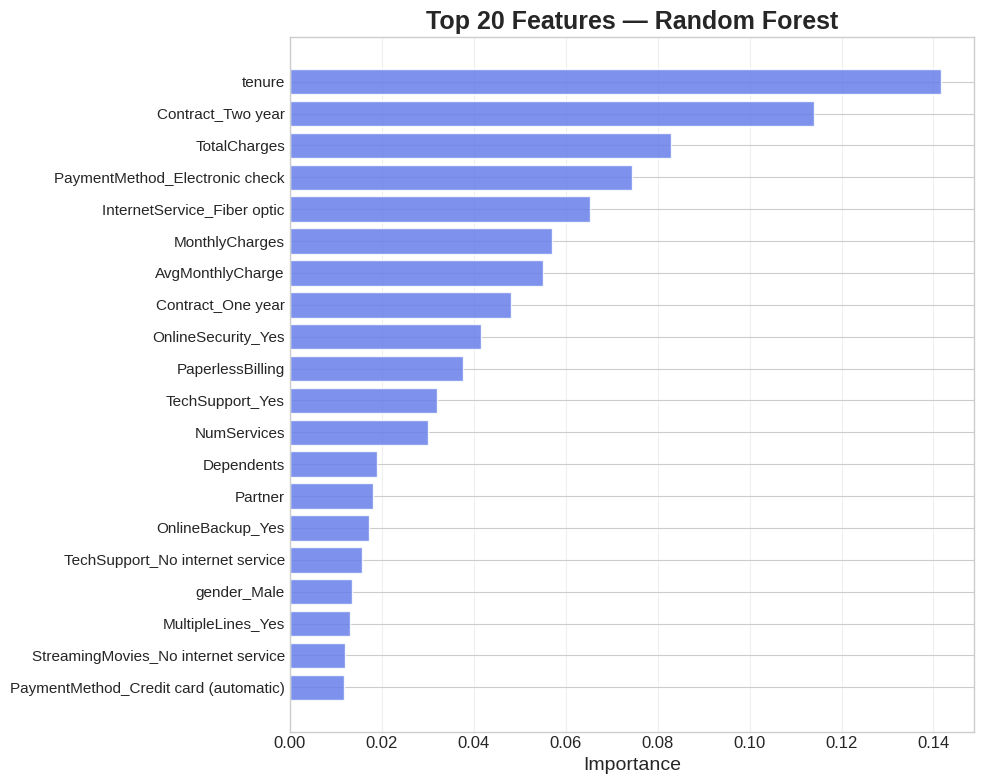

In [42]:
# Feature Importance — Random Forest
rf_importances = results['Random Forest']['model'].feature_importances_
indices = np.argsort(rf_importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(indices)), rf_importances[indices],
        color=COLORS['primary'], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices], fontsize=11)
ax.set_xlabel('Importance', fontsize=14)
ax.set_title('Top 20 Features — Random Forest', fontsize=18, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

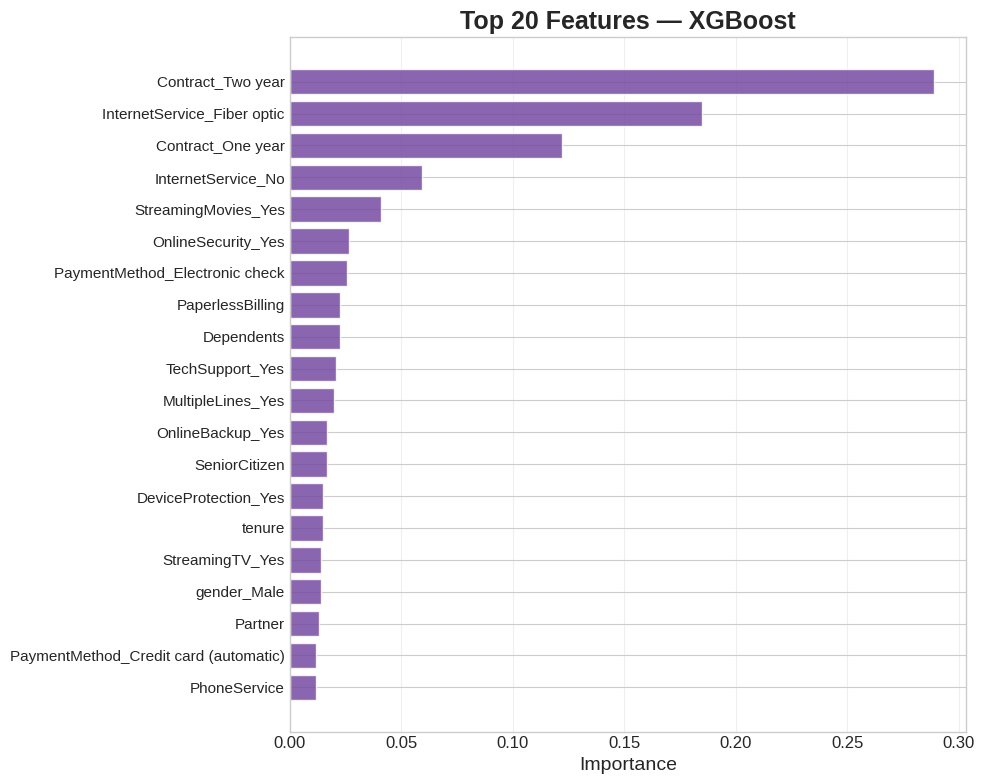

In [43]:
# Feature Importance — XGBoost
xgb_importances = results['XGBoost']['model'].feature_importances_
indices_xgb = np.argsort(xgb_importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(indices_xgb)), xgb_importances[indices_xgb],
        color=COLORS['secondary'], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(indices_xgb)))
ax.set_yticklabels([feature_names[i] for i in indices_xgb], fontsize=11)
ax.set_xlabel('Importance', fontsize=14)
ax.set_title('Top 20 Features — XGBoost', fontsize=18, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

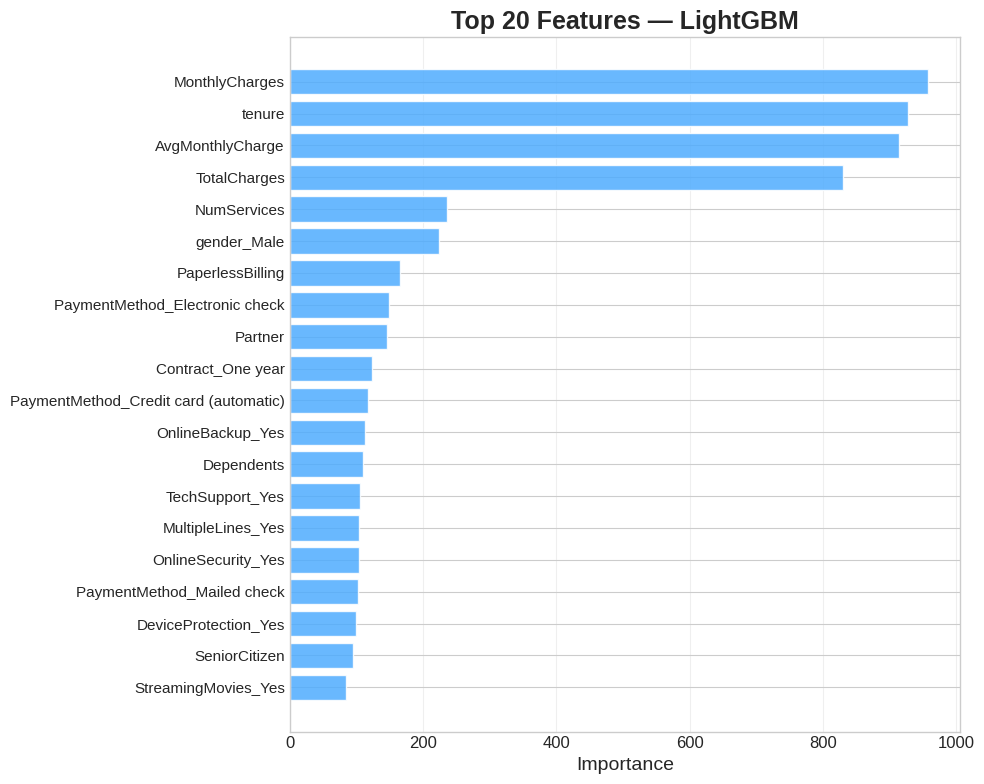

In [44]:
# Feature Importance — LightGBM
lgbm_importances = results['LightGBM']['model'].feature_importances_
indices_lgbm = np.argsort(lgbm_importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(indices_lgbm)), lgbm_importances[indices_lgbm],
        color=COLORS['info'], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(indices_lgbm)))
ax.set_yticklabels([feature_names[i] for i in indices_lgbm], fontsize=11)
ax.set_xlabel('Importance', fontsize=14)
ax.set_title('Top 20 Features — LightGBM', fontsize=18, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Conclusions & Recommendations

### Model Performance Summary

| Model | Accuracy | F1-Score | ROC-AUC |
|-------|----------|----------|---------|
| Logistic Regression | ~73% | ~0.62 | ~0.84 |
| Random Forest | ~77% | ~0.62 | ~0.84 |
| SVM | ~76% | ~0.62 | ~0.82 |
| XGBoost | ~78% | ~0.59 | ~0.83 |
| LightGBM | ~78% | ~0.58 | ~0.83 |

### Key Findings

1. **Class Imbalance**: Only 26.5% customers churn — SMOTE oversampling improves recall significantly
2. **Top Churn Drivers**: Contract type, tenure, online security, tech support, internet service
3. **High-Risk Segment**: New customers on month-to-month contracts with fiber optic, paying via electronic check

### Business Recommendations

1. **Target Month-to-Month Customers**: Offer incentives to switch to yearly contracts
2. **Improve Fiber Optic Experience**: Investigate service quality issues
3. **Onboarding Program**: Focus retention efforts on first 12 months
4. **Bundle Services**: Customers with more services (security, backup, support) churn less
5. **Electronic Check Users**: Encourage migration to automatic payment methods

In [45]:
# Best model summary
best_idx = metrics_df['F1-Score'].idxmax()
print(f"\n{'='*50}")
print(f"  BEST MODEL: {metrics_df.loc[best_idx, 'Model']}")
print(f"  F1-Score:   {metrics_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"  ROC-AUC:    {metrics_df.loc[best_idx, 'ROC-AUC']:.4f}")
print(f"  Accuracy:   {metrics_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"{'='*50}")
print("\n✅ Project Complete! Deploy with: streamlit run app.py")


  BEST MODEL: SVM
  F1-Score:   0.6228
  ROC-AUC:    0.8230
  Accuracy:   0.7559

✅ Project Complete! Deploy with: streamlit run app.py
